### Este notebook modela el enfriamiento de Newton usando el metodo de Euler para resolver ecuaciones diferenciales lineales


In [14]:
from math_core.ode.euler_method import euler_solve
import matplotlib.pyplot as plt

La ecuacion diferencial que modela el cambio de temperatura de un objeto es de la forma $\frac{dT}{dt} = -k(T-T_{amb})$ donde:
* $T$ es la temperatura del objeto en el tiempo t 
* $k>0$ es la constante de enfriamiento 
* $T_{amb}$ es la temperatura ambiente
El cambio de temperatura conforme avanza el tiempo es proporcional a la temperatura del objeto menos la temperaura ambiente

## Ejemplo 1 
si tenemos que un cafe se calento a 100 grados y la temperatura de la casa es de 8. La temperatura del café 5 minutos despues de sacarlo es de 55 entonces podemos saber cual sera su temperatura en cualquier momento. 

haciendo algunos despejes podemos encontrar la constante de enfriamiento:
* $k = 0.1345$

In [16]:
def temperatura(t, y):
    k = 0.1345
    Ta = 8
    T = y[0]  
    return -k * (T - Ta)

funciones = [temperatura]

# la condicion inicial va en lista aunque sea una sola ecuacion
tiempos, valores = euler_solve(funciones, [100], 0, 40, 0.5)

# valores[0] es la lista de temperaturas
print(tiempos)
print(valores[0])

[0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 40.5]
[100, 93.813, 88.04207575000001, 82.65924615581251, 77.63841185183412, 72.95522865479828, 68.5869895277631, 64.51251448202103, 60.712047883105114, 57.1671626629663, 53.86067097388182, 50.77654085088827, 47.899818478666035, 45.21655568597574, 42.71374231609387, 40.37924314533656, 38.20173904381267, 36.170672093116266, 34.276194394854194, 32.509120321800246, 30.860881980159178, 29.323487666993472, 27.88948312138816, 26.551915381474807, 25.304299072070627, 24.140584959473877, 23.05513062094926, 22.04267308669042, 21.0983033216

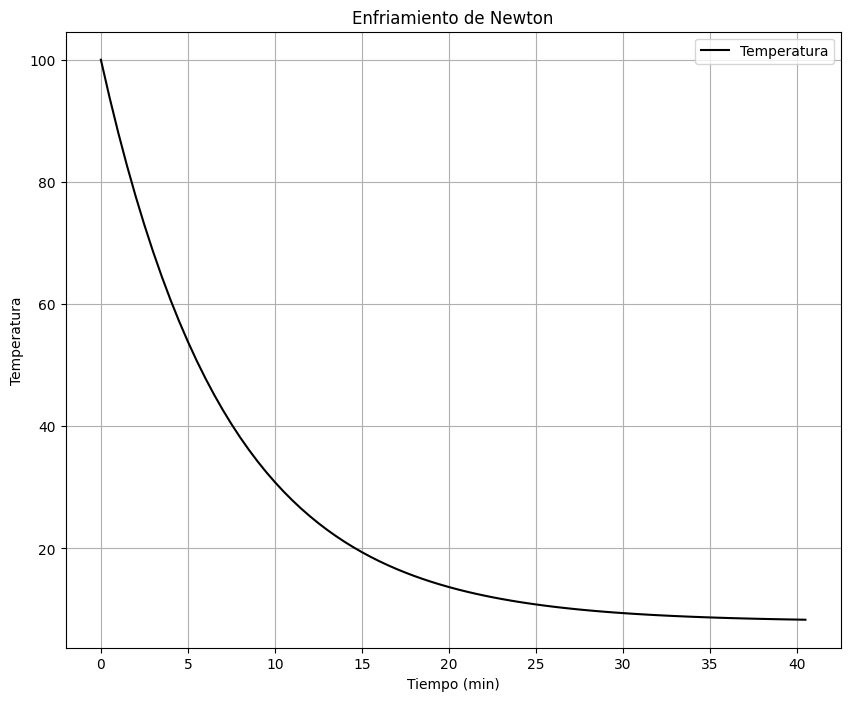

In [21]:
plt.figure(figsize=(10,8))
plt.plot(tiempos, valores[0], label="Temperatura", color="black")
plt.xlabel("Tiempo (min)")
plt.ylabel("Temperatura")
plt.title("Enfriamiento de Newton")
plt.legend()
plt.grid(True)
plt.show()

## Ejemplo 2
#### Sistema de dos ecuaciones 
Suponiendo que hay dos cuartos con diferentes temperaturas cada uno, que estan conectados con una puerta aislante (o sea que no hay interferencia de otras temperaturas) podemos usar la ley de enfriamiento de Newton pero cambiando un poco.
 
Si tenemos la sala $P$ y $Q$ donde la sala $P$ tiene menor temperatura que $Q$ entonces las ecuaciones diferenciales (que estan relacionadas) se comportarian:
$$\frac{dP}{dt} > 0,  \frac{dQ}{dt} < 0$$
Podemos usar la ley de Newton $\frac{dT}{dt} = -k(T-T_{amb})$ y la modificamos un poco, quedandonos:

\begin{cases} 
\frac{dP}{dt} = k(Q-P)\\
\frac{dQ}{dt} = -k(Q-P)
\end{cases}
$$k>0$$
Que describe los cambios de temperatura de las dos salas y lo que gana la primer sala es lo mismo que pierde la segunda (un sistema de intercambio)

Si la temperatura inicial en el cuarto P es de 9 y de Q de 33 y a los 6 minutos $P_1 = 13$
entonces con los datos de $P_0, P_1$ podemos encontrar la constante $k$ 
ya tenemos los datos:
$$P_0 = 9 , Q_0 = 33, k=1/36$$

In [32]:
#constante de proporcion de calor 
k = 1/36

#creamos las dos ecuaciones diferenciales
def dP(t, y):
    #y deberia ser una lista con los valor [Pn, Qn]
    P = y[0]
    Q = y[1]
    return k * (Q - P)

def dQ(t, y):
    #y deberia ser una lista con los valor [Pn, Qn]
    P = y[0]
    Q = y[1]
    return -k * (Q - P)

sistema = [dP, dQ]
condiciones = [9.0, 33.0]

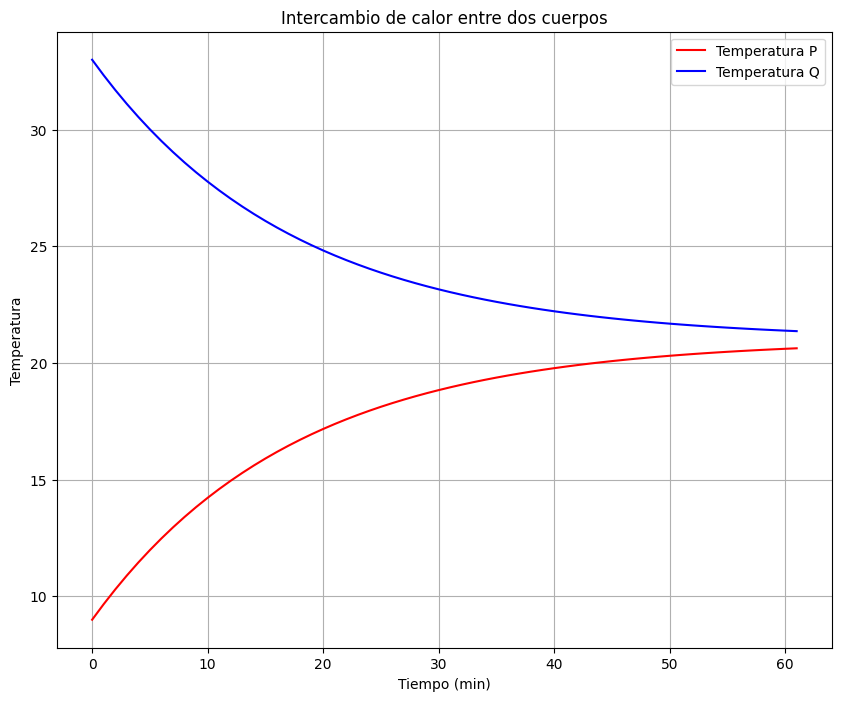

In [35]:
tiempos, valores = euler_solve(sistema, condiciones, 0, 60, 1)

plt.figure(figsize=(10,8))
plt.plot(tiempos, valores[0], label="Temperatura P", color="red")
plt.plot(tiempos, valores[1], label="Temperatura Q", color="blue")
plt.xlabel("Tiempo (min)")
plt.ylabel("Temperatura")
plt.title("Intercambio de calor entre dos cuerpos")
plt.legend()
plt.grid(True)
plt.show()